In [1]:
!pip install -q segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.8 MB/s eta 0:00:00


In [2]:
import os, cv2, numpy as np, torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from google.colab import drive

CONFIG = {
    "image_dir"     : "/content/drive/MyDrive/FYP/data/images",
    "mask_dir"      : "/content/drive/MyDrive/FYP/data/masks",
    "image_size"    : 256,
    "num_classes"   : 5,
    "batch_size"    : 8,
    "epochs"        : 60,
    "lr"            : 3e-4,
    "encoder_lr"    : 3e-5,
    "freeze_epochs" : 10,
    "seed"          : 42,
    "save_path"     : "/content/drive/MyDrive/FYP/model1_unetpp_effb4_best.pth",
}

NUM_CLASSES = 5

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

Device : cuda


In [3]:
drive.mount("/content/drive")

NUM_CLASSES = 5

CLASS_INFO = {
    0: {"name": "Background",    "rgb": (0,   0,   0)},
    1: {"name": "Retinal Layer", "rgb": (255, 0,   255)},
    2: {"name": "PED",           "rgb": (255, 255, 0)},
    3: {"name": "SRF",           "rgb": (255, 0,   0)},
    4: {"name": "IRF",           "rgb": (0,   0,   255)},
}

print("── Class Mapping ─────────────────────────────────────")
for cls_id, info in CLASS_INFO.items():
    r, g, b = info["rgb"]
    print(f"  Class {cls_id}: {info['name']:<18} RGB({r:3d},{g:3d},{b:3d})")

Mounted at /content/drive
── Class Mapping ─────────────────────────────────────
  Class 0: Background         RGB(  0,  0,  0)
  Class 1: Retinal Layer      RGB(255,  0,255)
  Class 2: PED                RGB(255,255,  0)
  Class 3: SRF                RGB(255,  0,  0)
  Class 4: IRF                RGB(  0,  0,255)


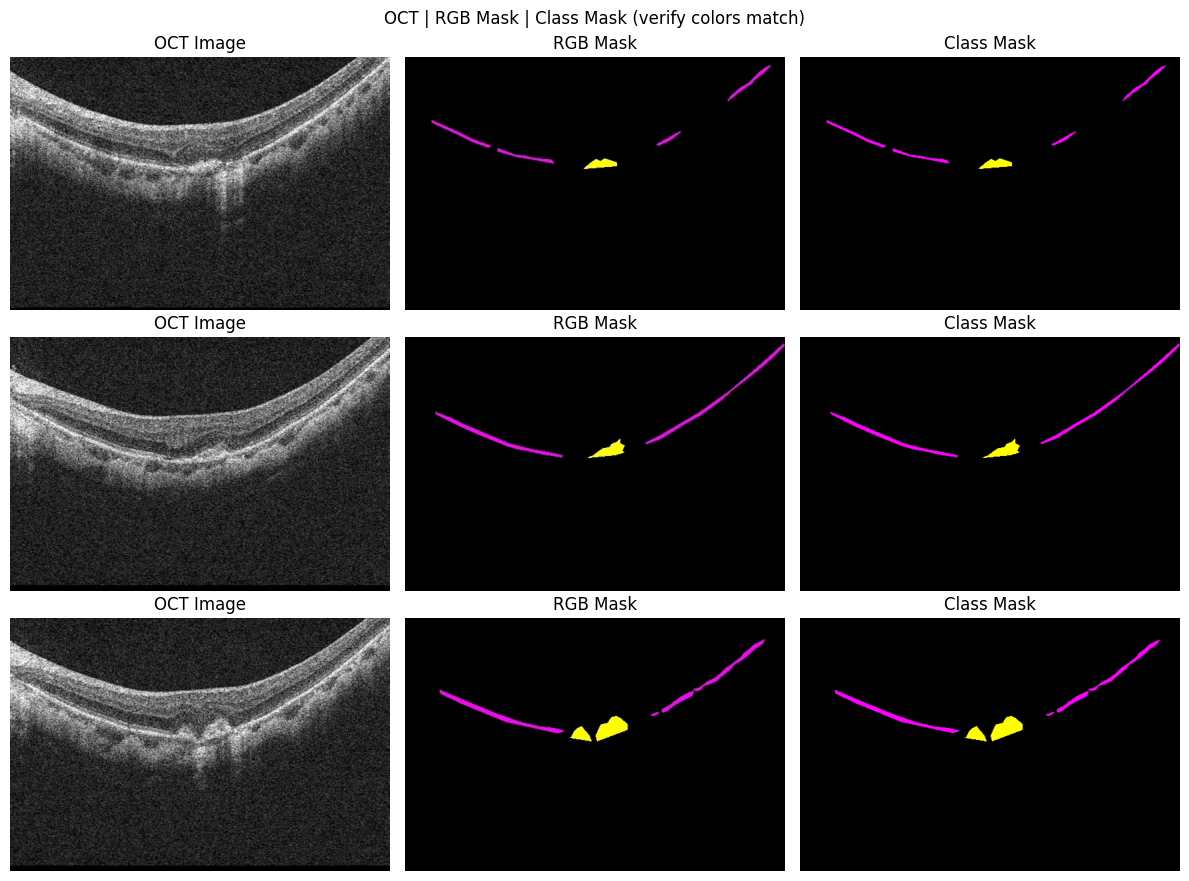

In [4]:
def rgb_mask_to_class(mask_bgr, class_info, tolerance=40):
    mask_rgb   = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)
    h, w, _    = mask_rgb.shape
    pixels     = mask_rgb.reshape(-1, 3).astype(np.float32)
    best_dist  = np.full(len(pixels), np.inf)
    best_cls   = np.zeros(len(pixels), dtype=np.uint8)

    for cls_id, info in class_info.items():
        ref  = np.array(info["rgb"], dtype=np.float32)
        dist = np.linalg.norm(pixels - ref, axis=1)
        mask_better = dist < best_dist
        best_dist[mask_better] = dist[mask_better]
        best_cls[mask_better]  = cls_id

    return best_cls.reshape(h, w)


CLASS_COLORS_VIZ = [
    [0,   0,   0  ],
    [255, 0,   255],
    [255, 255, 0  ],
    [255, 0,   0  ],
    [0,   0,   255],
]

def mask_to_rgb(mask_np):
    h, w = mask_np.shape
    rgb  = np.zeros((h, w, 3), dtype=np.uint8)
    for c in range(NUM_CLASSES):
        rgb[mask_np == c] = CLASS_COLORS_VIZ[c]
    return rgb


# ── Verify on 3 samples ───────────────────────────────────────────────────────
img_files  = sorted([f for f in os.listdir(CONFIG["image_dir"])
                     if f.lower().endswith(('.png','.jpg','.tif','.bmp'))])
mask_files = sorted([f for f in os.listdir(CONFIG["mask_dir"])
                     if f.lower().endswith(('.png','.jpg','.tif','.bmp'))])

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
fig.suptitle("OCT | RGB Mask | Class Mask (verify colors match)",
             fontsize=12)

for i in range(3):
    fname    = img_files[i]
    img      = cv2.imread(os.path.join(CONFIG["image_dir"], fname),
                          cv2.IMREAD_GRAYSCALE)
    mask_bgr = cv2.imread(os.path.join(CONFIG["mask_dir"],  fname),
                          cv2.IMREAD_COLOR)
    mask_rgb = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)
    cls_mask = rgb_mask_to_class(mask_bgr, CLASS_INFO)
    vis      = mask_to_rgb(cls_mask)

    axes[i,0].imshow(img,     cmap="gray");  axes[i,0].set_title("OCT Image")
    axes[i,1].imshow(mask_rgb);              axes[i,1].set_title("RGB Mask")
    axes[i,2].imshow(vis);                   axes[i,2].set_title("Class Mask")
    for ax in axes[i]: ax.axis("off")

plt.tight_layout()
plt.savefig("/content/verification.png", dpi=120)
plt.show()

In [5]:
class OCTDataset(Dataset):
    def __init__(self, image_dir, mask_dir, class_info, transform=None):
        self.image_dir  = image_dir
        self.mask_dir   = mask_dir
        self.class_info = class_info
        self.transform  = transform
        self.ids = sorted([f for f in os.listdir(image_dir)
                           if f.lower().endswith(('.png','.jpg','.tif','.bmp'))])

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        fname    = self.ids[idx]
        img      = cv2.imread(os.path.join(self.image_dir, fname),
                              cv2.IMREAD_GRAYSCALE)
        mask_bgr = cv2.imread(os.path.join(self.mask_dir,  fname),
                              cv2.IMREAD_COLOR)

        img      = cv2.resize(img,
                              (CONFIG["image_size"], CONFIG["image_size"]))
        mask_bgr = cv2.resize(mask_bgr,
                              (CONFIG["image_size"], CONFIG["image_size"]),
                              interpolation=cv2.INTER_NEAREST)
        mask     = rgb_mask_to_class(mask_bgr, self.class_info)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug["image"]
            mask = aug["mask"].long()
        else:
            img  = torch.tensor(img, dtype=torch.float32).unsqueeze(0) / 255.0
            mask = torch.tensor(mask, dtype=torch.long)

        return img, mask


def get_transforms(train=True):
    norm = [
        A.Normalize(mean=(0.5,), std=(0.5,), max_pixel_value=255.0),
        ToTensorV2(),
    ]
    if train:
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                               rotate_limit=15, p=0.4),
            A.RandomBrightnessContrast(p=0.4),
            A.GaussNoise(p=0.3),
            A.GaussianBlur(blur_limit=3, p=0.2),
            A.GridDistortion(p=0.2),
            A.CLAHE(clip_limit=4.0, p=0.3),
            *norm,
        ])
    return A.Compose(norm)


full_ds = OCTDataset(CONFIG["image_dir"], CONFIG["mask_dir"], CLASS_INFO)
n       = len(full_ds)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(CONFIG["seed"])
)
train_ds.dataset.transform = get_transforms(train=True)
val_ds.dataset.transform   = get_transforms(train=False)
test_ds.dataset.transform  = get_transforms(train=False)

pin = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"],
                          shuffle=True,  num_workers=2, pin_memory=pin)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=2, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=2, pin_memory=pin)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 2134 | Val: 457 | Test: 458


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [6]:
model = smp.UnetPlusPlus(
    encoder_name         = "efficientnet-b4",
    encoder_weights      = "imagenet",
    in_channels          = 1,
    classes              = NUM_CLASSES,
    activation           = None,
    decoder_channels     = (256, 128, 64, 32, 16),
    decoder_use_batchnorm= True,
)
model = model.to(device)

total = sum(p.numel() for p in model.parameters())
enc   = sum(p.numel() for p in model.encoder.parameters())
dec   = sum(p.numel() for p in model.decoder.parameters())
print(f"Model         : UNet++ EfficientNet-B4  (Model 1)")
print(f"Encoder params: {enc:>12,}  ← ImageNet pretrained")
print(f"Decoder params: {dec:>12,}  ← randomly initialized")
print(f"Total params  : {total:>12,}  ({total/1e6:.1f}M)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Model         : UNet++ EfficientNet-B4  (Model 1)
Encoder params:   17,547,752  ← ImageNet pretrained
Decoder params:    3,264,352  ← randomly initialized
Total params  :   20,812,829  (20.8M)


In [7]:
def compute_class_weights_rgb(mask_dir, class_info, n_classes, n_samples=100):
    counts = np.zeros(n_classes, dtype=np.float64)
    files  = sorted([f for f in os.listdir(mask_dir)
                     if f.lower().endswith(('.png','.jpg','.tif','.bmp'))])[:n_samples]
    for f in files:
        mask_bgr = cv2.imread(os.path.join(mask_dir, f), cv2.IMREAD_COLOR)
        cls_mask = rgb_mask_to_class(mask_bgr, class_info)
        for c in range(n_classes):
            counts[c] += np.sum(cls_mask == c)

    freq    = counts / counts.sum()
    median  = np.median(freq)
    weights = median / (freq + 1e-6)
    weights = np.clip(weights, 0.1, 10.0)
    weights = weights / weights.sum() * n_classes

    print("── Class Weights ─────────────────────────────────────")
    for i, (cnt, w) in enumerate(zip(counts, weights)):
        pct  = 100 * cnt / counts.sum()
        name = class_info[i]["name"]
        print(f"  Class {i} {name:<18}: {pct:5.1f}%  → weight {w:.4f}")
    return torch.tensor(weights, dtype=torch.float32).to(device)

CLASS_WEIGHTS = compute_class_weights_rgb(
    CONFIG["mask_dir"], CLASS_INFO, NUM_CLASSES
)

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds   = F.softmax(preds, dim=1)
        one_hot = F.one_hot(targets, NUM_CLASSES).permute(0,3,1,2).float()
        inter   = (preds * one_hot).sum(dim=(2,3))
        union   = preds.sum(dim=(2,3)) + one_hot.sum(dim=(2,3))
        dice    = (2.0 * inter + self.smooth) / (union + self.smooth)
        return 1.0 - dice.mean()

class CombinedLoss(nn.Module):
    def __init__(self, weights, alpha=0.5):
        super().__init__()
        self.ce   = nn.CrossEntropyLoss(weight=weights)
        self.dice = DiceLoss()
        self.alpha = alpha

    def forward(self, preds, targets):
        return self.alpha * self.ce(preds, targets) \
             + (1 - self.alpha) * self.dice(preds, targets)

def dice_score(preds, targets, smooth=1e-6):
    preds = preds.argmax(dim=1)
    scores = []
    for c in range(NUM_CLASSES):
        p     = (preds == c).float()
        t     = (targets == c).float()
        inter = (p * t).sum()
        scores.append((2*inter + smooth) / (p.sum() + t.sum() + smooth))
    return torch.stack(scores).mean().item()

def iou_score(preds, targets, smooth=1e-6):
    preds = preds.argmax(dim=1)
    scores = []
    for c in range(NUM_CLASSES):
        p     = (preds == c).float()
        t     = (targets == c).float()
        inter = (p * t).sum()
        union = p.sum() + t.sum() - inter
        scores.append((inter + smooth) / (union + smooth))
    return torch.stack(scores).mean().item()

def per_class_dice(preds, targets, smooth=1e-6):
    preds = preds.argmax(dim=1)
    scores = []
    for c in range(NUM_CLASSES):
        p     = (preds == c).float()
        t     = (targets == c).float()
        inter = (p * t).sum()
        scores.append(((2*inter+smooth)/(p.sum()+t.sum()+smooth)).item())
    return scores

criterion = CombinedLoss(weights=CLASS_WEIGHTS, alpha=0.5)

dummy_pred = torch.randn(2, NUM_CLASSES, 64, 64).to(device)
dummy_mask = torch.randint(0, NUM_CLASSES, (2, 64, 64)).to(device)
test_loss  = criterion(dummy_pred, dummy_mask)
print(f"\nSanity check loss: {test_loss.item():.4f}")
print("PASS ✓" if test_loss.item() > 0 else "FAIL ✗ — do not proceed")

── Class Weights ─────────────────────────────────────
  Class 0 Background        :  97.4%  → weight 0.0719
  Class 1 Retinal Layer     :   0.5%  → weight 1.2246
  Class 2 PED               :   0.9%  → weight 0.7188
  Class 3 SRF               :   0.3%  → weight 2.3013
  Class 4 IRF               :   0.9%  → weight 0.6835

Sanity check loss: 1.3877
PASS ✓


In [8]:
def freeze_encoder(m):
    for param in m.encoder.parameters():
        param.requires_grad = False
    print("Encoder FROZEN — only decoder training")

def unfreeze_encoder(m):
    for param in m.encoder.parameters():
        param.requires_grad = True
    print("Encoder UNFROZEN — full model training")

def make_optimizer(m, frozen=False):
    if frozen:
        return torch.optim.AdamW(
            filter(lambda p: p.requires_grad, m.parameters()),
            lr=CONFIG["lr"], weight_decay=1e-4
        )
    return torch.optim.AdamW([
        {"params": m.encoder.parameters(),           "lr": CONFIG["encoder_lr"]},
        {"params": m.decoder.parameters(),           "lr": CONFIG["lr"]},
        {"params": m.segmentation_head.parameters(), "lr": CONFIG["lr"]},
    ], weight_decay=1e-4)

def run_epoch(loader, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss = total_dice = total_iou = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            loss  = criterion(preds, masks)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()
            total_dice += dice_score(preds.detach(), masks)
            total_iou  += iou_score(preds.detach(),  masks)
    n = len(loader)
    return total_loss/n, total_dice/n, total_iou/n

history   = {"train_loss":[],"val_loss":[],"val_dice":[],"val_iou":[]}
best_dice = 0.0
FREEZE_EP = CONFIG["freeze_epochs"]

freeze_encoder(model)
optimizer = make_optimizer(model, frozen=True)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=FREEZE_EP, eta_min=1e-6)

print(f"\nPhase 1 — Epochs 1–{FREEZE_EP}: decoder only")
print(f"{'Epoch':>6} {'Train Loss':>11} {'Val Loss':>10} "
      f"{'Val Dice':>10} {'Val IoU':>9} {'':>8}")
print("-" * 62)

for epoch in range(1, CONFIG["epochs"] + 1):
    if epoch == FREEZE_EP + 1:
        unfreeze_encoder(model)
        optimizer = make_optimizer(model, frozen=False)
        scheduler = CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=2, eta_min=1e-6)
        print(f"\nPhase 2 — Epochs {FREEZE_EP+1}–{CONFIG['epochs']}: full fine-tuning\n")
        print(f"{'Epoch':>6} {'Train Loss':>11} {'Val Loss':>10} "
              f"{'Val Dice':>10} {'Val IoU':>9} {'':>8}")
        print("-" * 62)

    tr_loss, _, _               = run_epoch(train_loader, optimizer, train=True)
    val_loss, val_dice, val_iou = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["val_iou"].append(val_iou)

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "dice": best_dice, "config": CONFIG},
                   CONFIG["save_path"])
        status = "saved"
    else:
        status = ""

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} {tr_loss:>11.4f} {val_loss:>10.4f} "
              f"{val_dice:>10.4f} {val_iou:>9.4f} {status:>8}")

print(f"\nTraining complete — Best Val Dice: {best_dice:.4f}")

Encoder FROZEN — only decoder training

Phase 1 — Epochs 1–10: decoder only
 Epoch  Train Loss   Val Loss   Val Dice   Val IoU         
--------------------------------------------------------------
     1      0.5452     0.4334     0.6254    0.5039    saved
     5      0.2431     0.2661     0.8206    0.7156    saved
    10      0.1405     0.2240     0.8278    0.7255    saved
Encoder UNFROZEN — full model training

Phase 2 — Epochs 11–60: full fine-tuning

 Epoch  Train Loss   Val Loss   Val Dice   Val IoU         
--------------------------------------------------------------
    15      0.1192     0.2060     0.8344    0.7356         
    20      0.0858     0.2078     0.8496    0.7538         
    25      0.0941     0.2033     0.8407    0.7438         
    30      0.0764     0.2124     0.8458    0.7515         
    35      0.0652     0.2141     0.8592    0.7682    saved
    40      0.0612     0.2156     0.8585    0.7676         
    45      0.0776     0.2102     0.8492    0.7562      

In [9]:
ckpt = torch.load(CONFIG["save_path"], map_location=device)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best checkpoint — epoch {ckpt['epoch']} "
      f"(Val Dice = {ckpt['dice']:.4f})\n")

test_loss, test_dice, test_iou = run_epoch(test_loader, train=False)
print("── Test Set Results ──────────────────────────────────────────")
print(f"  Loss : {test_loss:.4f}")
print(f"  Dice : {test_dice:.4f}")
print(f"  IoU  : {test_iou:.4f}")

# Per-class Dice
all_class_dice = [0.0] * NUM_CLASSES
all_class_iou  = [0.0] * NUM_CLASSES
n_batches      = 0
model.eval()

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks  = imgs.to(device), masks.to(device)
        preds        = model(imgs)
        pred_classes = preds.argmax(dim=1)
        for c in range(NUM_CLASSES):
            p     = (pred_classes == c).float()
            t     = (masks        == c).float()
            inter = (p * t).sum().item()
            union = (p + t - p * t).sum().item()
            all_class_dice[c] += (2*inter + 1e-6) / (p.sum().item() + t.sum().item() + 1e-6)
            all_class_iou[c]  += (inter   + 1e-6) / (union + 1e-6)
        n_batches += 1

class_names = ["Background", "Retinal Layer", "PED", "SRF", "IRF"]

print("\n── Per-Class Dice ────────────────────────────────────────────")
for name, score in zip(class_names, [s/n_batches for s in all_class_dice]):
    bar = "█" * int(score * 30)
    print(f"  {name:<18} {score:.4f}  {bar}")

print("\n── Per-Class IoU ─────────────────────────────────────────────")
for name, score in zip(class_names, [s/n_batches for s in all_class_iou]):
    bar = "█" * int(score * 30)
    print(f"  {name:<18} {score:.4f}  {bar}")

Loaded best checkpoint — epoch 39 (Val Dice = 0.8592)

── Test Set Results ──────────────────────────────────────────
  Loss : 0.2045
  Dice : 0.8613
  IoU  : 0.7685

── Per-Class Dice ────────────────────────────────────────────
  Background         0.9948  █████████████████████████████
  Retinal Layer      0.8169  ████████████████████████
  PED                0.7814  ███████████████████████
  SRF                0.8743  ██████████████████████████
  IRF                0.8391  █████████████████████████

── Per-Class IoU ─────────────────────────────────────────────
  Background         0.9896  █████████████████████████████
  Retinal Layer      0.6923  ████████████████████
  PED                0.6487  ███████████████████
  SRF                0.7810  ███████████████████████
  IRF                0.7307  █████████████████████


/tmp/ipykernel_3250/592401584.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


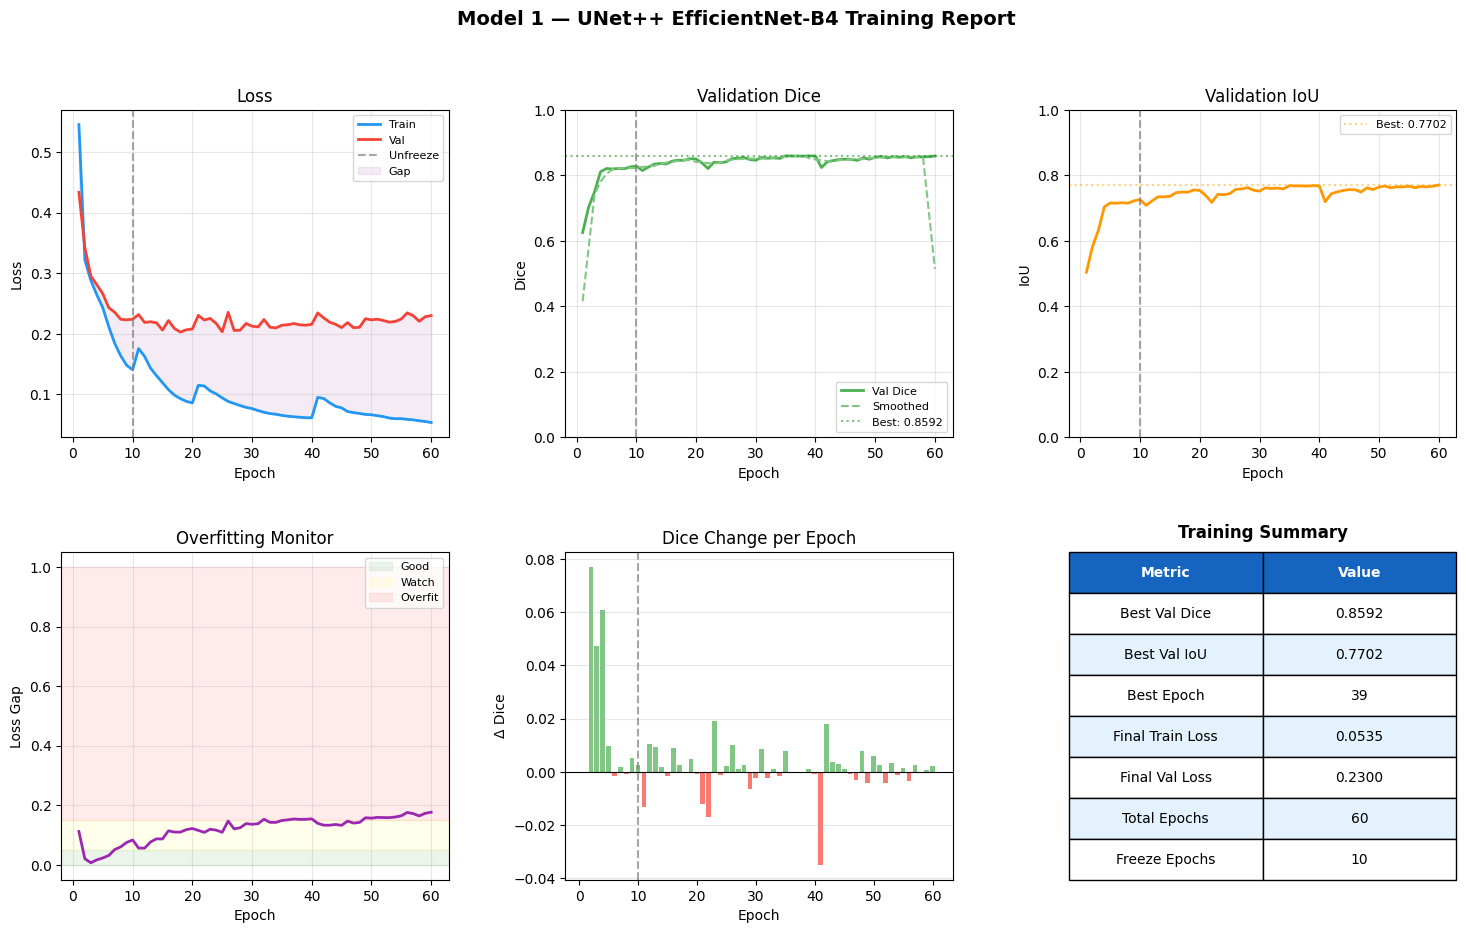

Saved → /content/model1_training_report.png


In [10]:
epochs    = list(range(1, len(history["train_loss"]) + 1))
freeze_ep = CONFIG["freeze_epochs"]

fig = plt.figure(figsize=(18, 10))
fig.suptitle("Model 1 — UNet++ EfficientNet-B4 Training Report",
             fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs, history["train_loss"], label="Train", color="#2196F3", linewidth=2)
ax1.plot(epochs, history["val_loss"],   label="Val",   color="#F44336", linewidth=2)
ax1.axvline(x=freeze_ep, color="gray", linestyle="--", alpha=0.7, label="Unfreeze")
ax1.fill_between(epochs, history["train_loss"], history["val_loss"],
                 alpha=0.08, color="purple", label="Gap")
ax1.set_title("Loss"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs, history["val_dice"], color="#4CAF50", linewidth=2, label="Val Dice")
smoothed = np.convolve(history["val_dice"], np.ones(5)/5, mode="same")
ax2.plot(epochs, smoothed, color="#81C784", linewidth=1.5,
         linestyle="--", label="Smoothed")
ax2.axvline(x=freeze_ep, color="gray", linestyle="--", alpha=0.7)
ax2.axhline(y=max(history["val_dice"]), color="green", linestyle=":",
            alpha=0.5, label=f"Best: {max(history['val_dice']):.4f}")
ax2.set_title("Validation Dice"); ax2.legend(fontsize=8)
ax2.grid(alpha=0.3); ax2.set_ylim([0, 1])
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Dice")

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(epochs, history["val_iou"], color="#FF9800", linewidth=2)
ax3.axvline(x=freeze_ep, color="gray", linestyle="--", alpha=0.7)
ax3.axhline(y=max(history["val_iou"]), color="orange", linestyle=":",
            alpha=0.5, label=f"Best: {max(history['val_iou']):.4f}")
ax3.set_title("Validation IoU"); ax3.legend(fontsize=8)
ax3.grid(alpha=0.3); ax3.set_ylim([0, 1])
ax3.set_xlabel("Epoch"); ax3.set_ylabel("IoU")

ax4 = fig.add_subplot(gs[1, 0])
gap = [abs(t-v) for t, v in zip(history["train_loss"], history["val_loss"])]
ax4.plot(epochs, gap, color="#9C27B0", linewidth=2)
ax4.axhspan(0,    0.05, alpha=0.08, color="green",  label="Good")
ax4.axhspan(0.05, 0.15, alpha=0.08, color="yellow", label="Watch")
ax4.axhspan(0.15, 1.00, alpha=0.08, color="red",    label="Overfit")
ax4.set_title("Overfitting Monitor"); ax4.legend(fontsize=8)
ax4.grid(alpha=0.3); ax4.set_xlabel("Epoch"); ax4.set_ylabel("Loss Gap")

ax5 = fig.add_subplot(gs[1, 1])
dice_delta = [0] + [history["val_dice"][i] - history["val_dice"][i-1]
                    for i in range(1, len(history["val_dice"]))]
colors = ["#4CAF50" if d >= 0 else "#F44336" for d in dice_delta]
ax5.bar(epochs, dice_delta, color=colors, alpha=0.7)
ax5.axhline(y=0, color="black", linewidth=0.8)
ax5.axvline(x=freeze_ep, color="gray", linestyle="--", alpha=0.7)
ax5.set_title("Dice Change per Epoch"); ax5.grid(alpha=0.3, axis="y")
ax5.set_xlabel("Epoch"); ax5.set_ylabel("Δ Dice")

ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
best_ep = history["val_dice"].index(max(history["val_dice"])) + 1
summary = [
    ["Metric",           "Value"],
    ["Best Val Dice",    f"{max(history['val_dice']):.4f}"],
    ["Best Val IoU",     f"{max(history['val_iou']):.4f}"],
    ["Best Epoch",       str(best_ep)],
    ["Final Train Loss", f"{history['train_loss'][-1]:.4f}"],
    ["Final Val Loss",   f"{history['val_loss'][-1]:.4f}"],
    ["Total Epochs",     str(len(epochs))],
    ["Freeze Epochs",    str(freeze_ep)],
]
table = ax6.table(cellText=summary[1:], colLabels=summary[0],
                  cellLoc="center", loc="center", bbox=[0,0,1,1])
table.auto_set_font_size(False); table.set_fontsize(10)
for j in range(2):
    table[0,j].set_facecolor("#1565C0")
    table[0,j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(summary)):
    for j in range(2):
        table[i,j].set_facecolor("#E3F2FD" if i%2==0 else "white")
ax6.set_title("Training Summary", fontweight="bold", pad=10)

plt.tight_layout()
plt.savefig("/content/model1_training_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/model1_training_report.png")

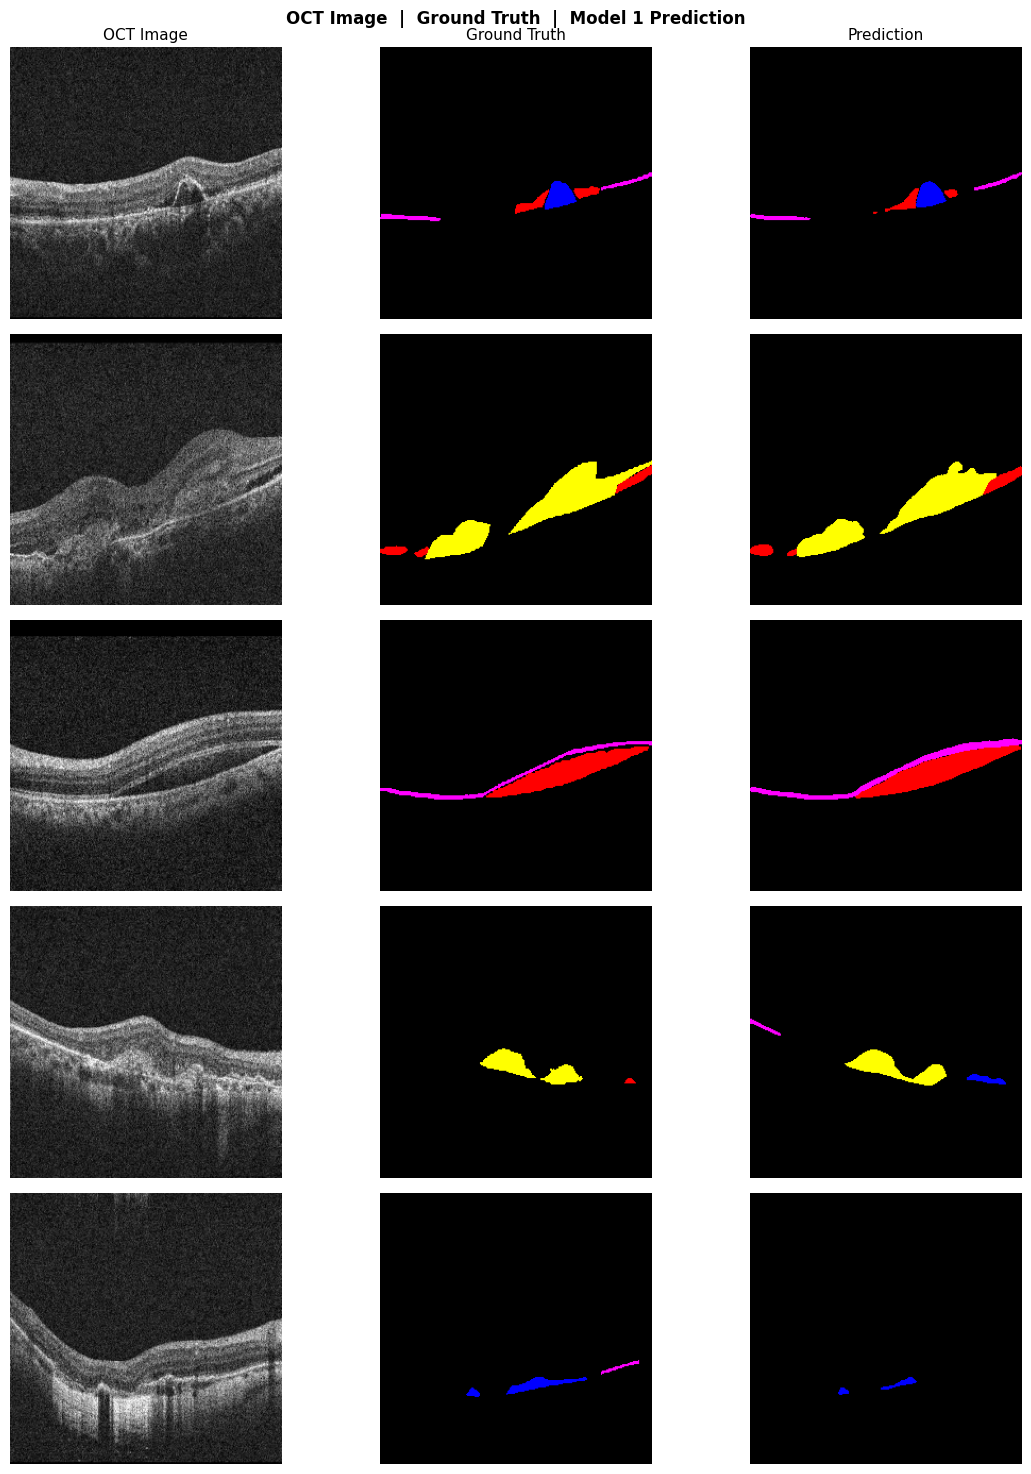

Saved → /content/model1_predictions.png


In [11]:
model.eval()
imgs, masks = next(iter(test_loader))

with torch.no_grad():
    preds = model(imgs.to(device)).argmax(dim=1).cpu()

n_show = min(5, len(imgs))
fig, axes = plt.subplots(n_show, 3, figsize=(12, n_show * 3))
fig.suptitle("OCT Image  |  Ground Truth  |  Model 1 Prediction",
             fontsize=12, fontweight="bold")

for i in range(n_show):
    axes[i,0].imshow(imgs[i].squeeze().numpy(), cmap="gray")
    axes[i,1].imshow(mask_to_rgb(masks[i].numpy()))
    axes[i,2].imshow(mask_to_rgb(preds[i].numpy()))
    for ax in axes[i]: ax.axis("off")
    if i == 0:
        for ax, t in zip(axes[0], ["OCT Image","Ground Truth","Prediction"]):
            ax.set_title(t, fontsize=11)

plt.tight_layout()
plt.savefig("/content/model1_predictions.png", dpi=150)
plt.show()
print("Saved → /content/model1_predictions.png")

In [12]:
PRED_DIR = "/content/drive/MyDrive/FYP/model1_predictions"
os.makedirs(PRED_DIR, exist_ok=True)

model.eval()
saved = 0

with torch.no_grad():
    for imgs, masks in test_loader:
        preds = model(imgs.to(device)).argmax(dim=1).cpu().numpy()
        for pred in preds:
            rgb = mask_to_rgb(pred)
            cv2.imwrite(
                os.path.join(PRED_DIR, f"pred_{saved:04d}.png"),
                cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
            )
            saved += 1

print(f"Saved {saved} predictions → {PRED_DIR}")

Saved 458 predictions → /content/drive/MyDrive/FYP/model1_predictions
